# 1) Load the data file and explore the data, showing size, and data distri-butions .

(7891, 10)


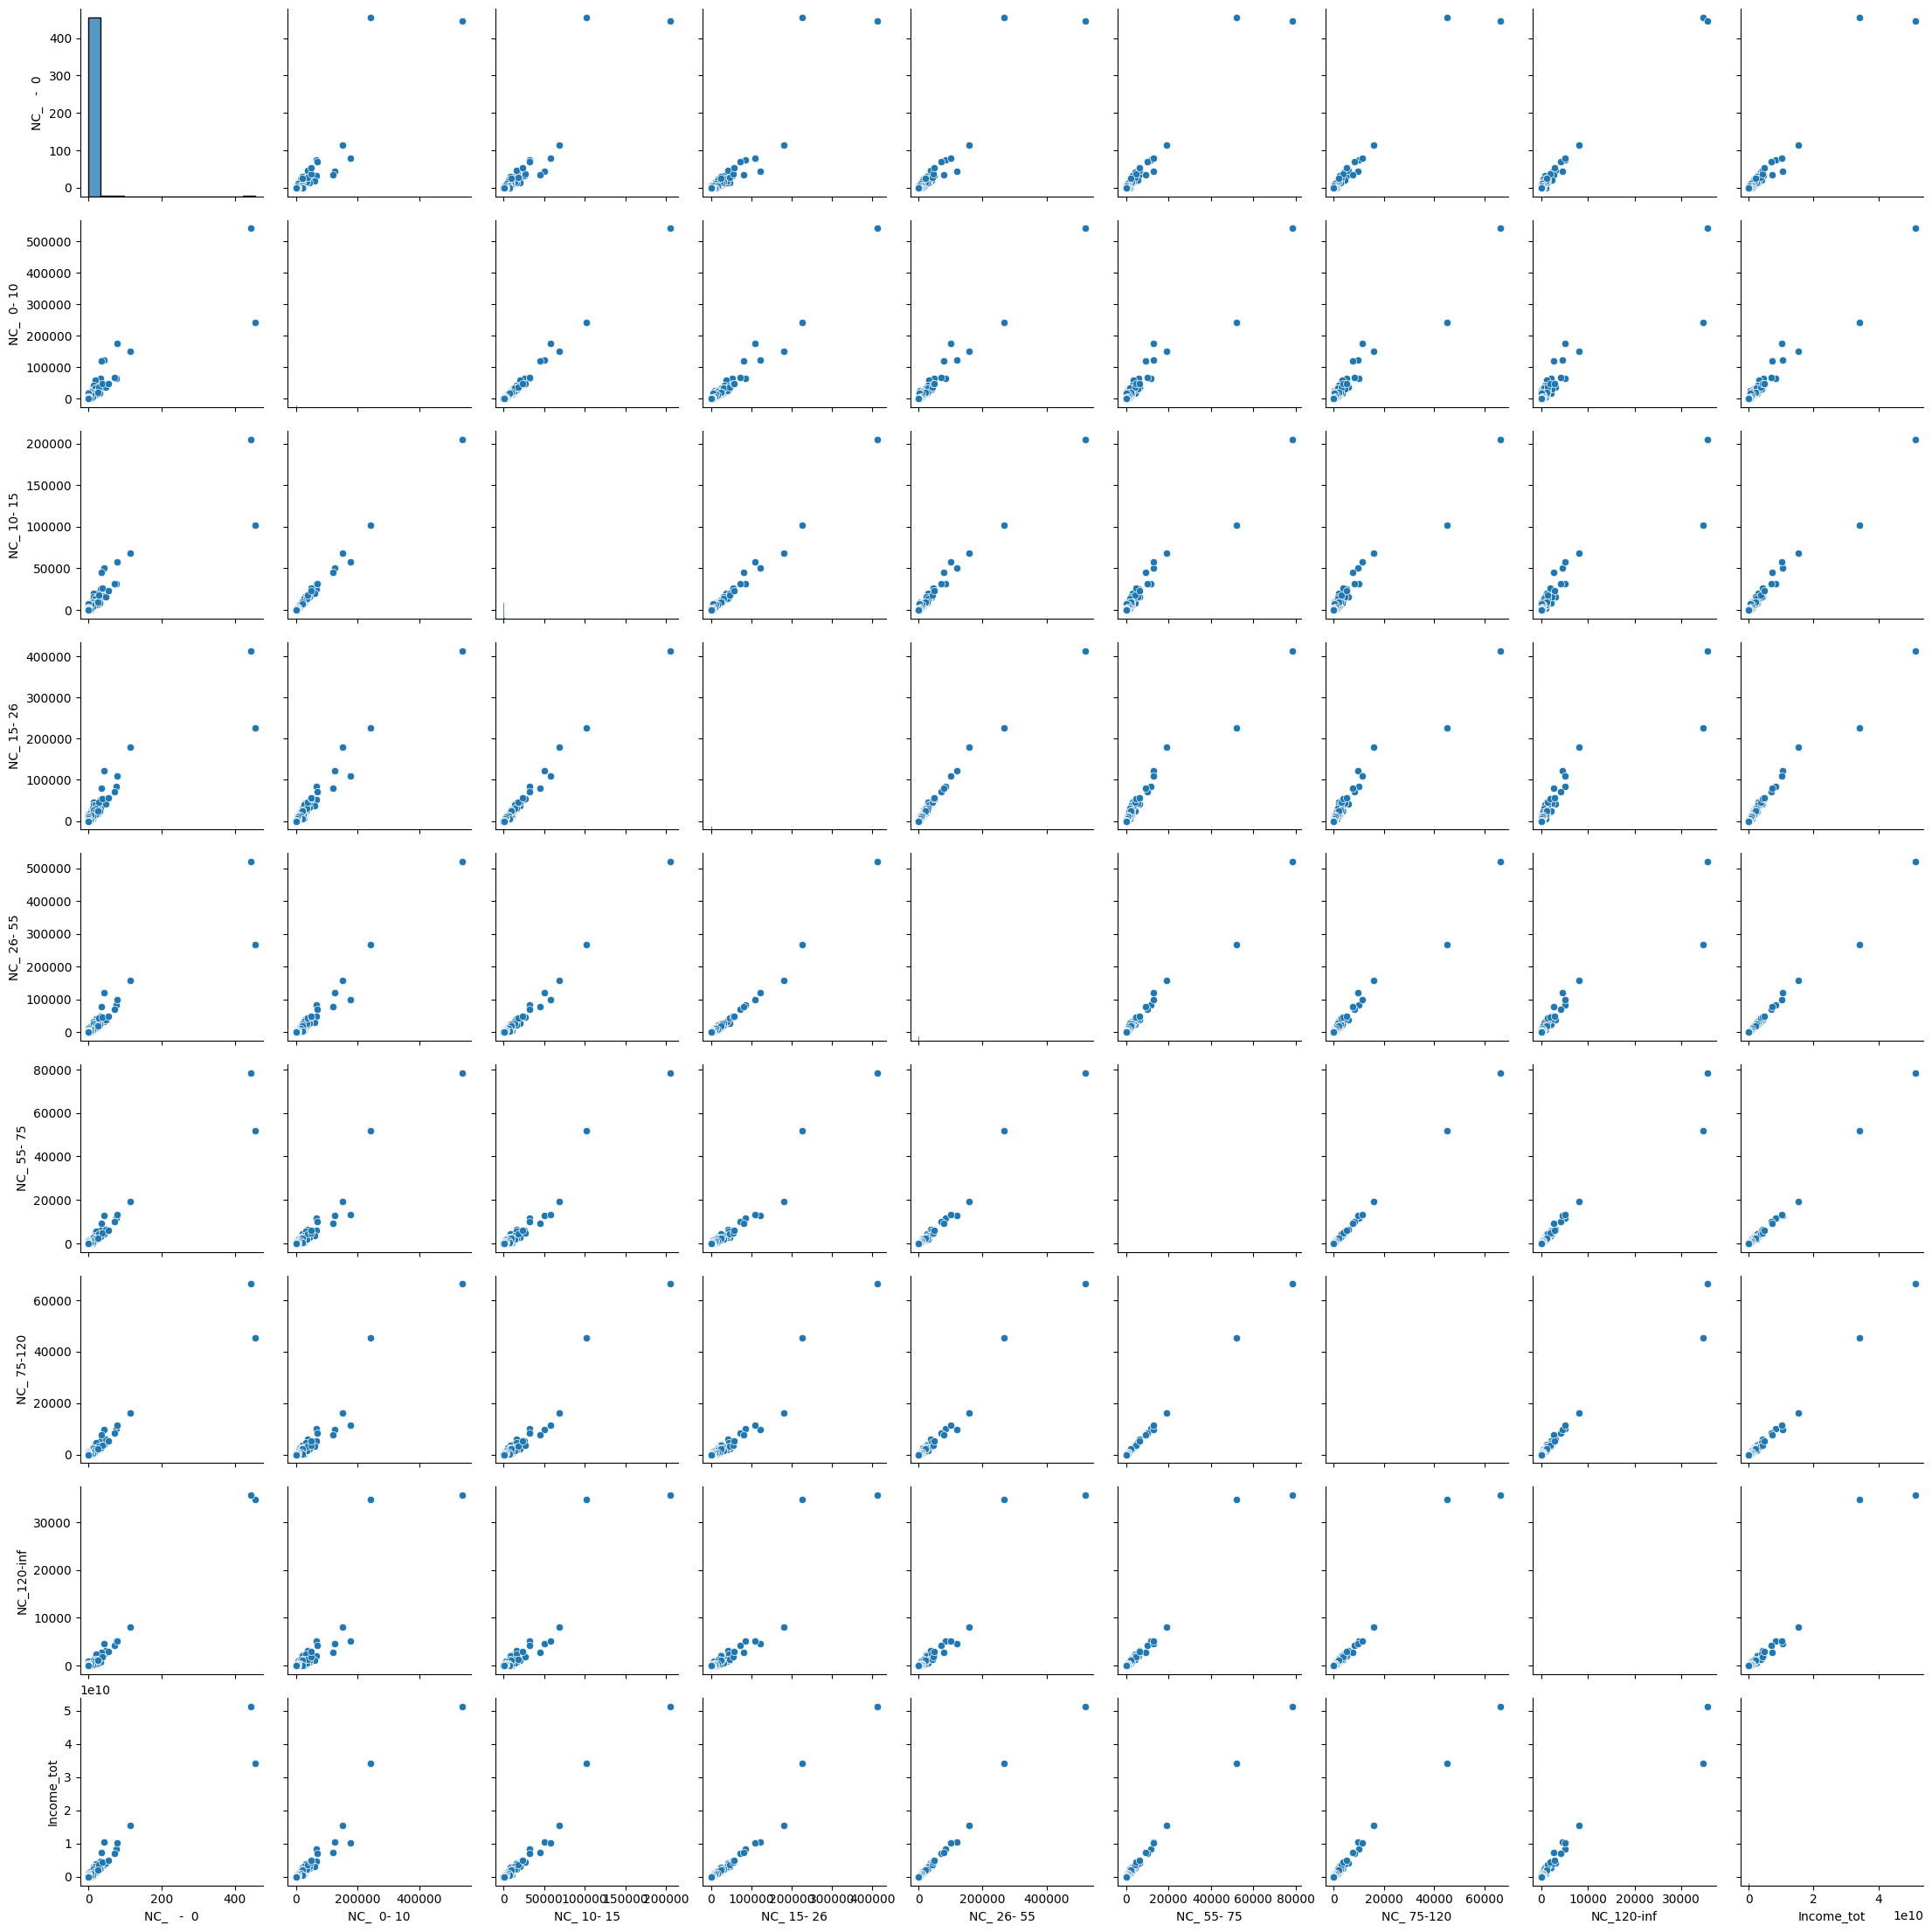

In [46]:
import pandas as pd
import seaborn as sns
import warnings 
warnings.filterwarnings("ignore")

data = pd.read_csv("./income.csv", index_col=0)
print(data.shape)
sns.pairplot(data);

# 2) drop the columns that are not relevant for the clustering operation, ifany, and explain why you do that 

- I already dropped the index colum in the previous point

- Drop "Territorio" as it is categorical but doesn not have duplicate values so it is not meaningful for clustering

In [47]:
len(data["Territorio"].unique())==data.shape[0]

True

In [48]:
df = data.drop(columns=["Territorio"])

# 3) find the best clustering scheme and compute: a) the quality indexesusual for clustering and b) the size of the clusters

Text(0, 0.5, 'Inertia')

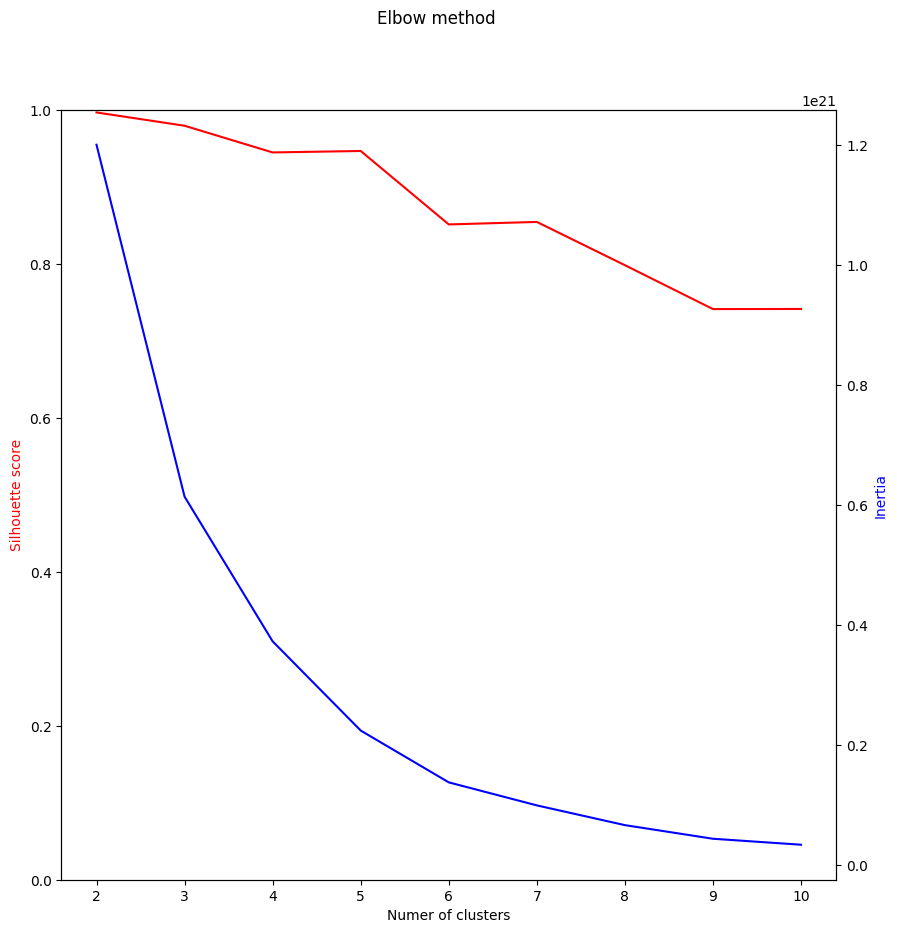

In [49]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt

silhouette_list = []
inertia_list = []
ks = [*range(2,11)]
random_state = 47
for k in ks:
    model = KMeans(n_clusters=k, random_state=random_state)
    y_pred = model.fit_predict(df)
    silhouette_list.append(silhouette_score(df, y_pred))
    inertia_list.append(model.inertia_)
    
fig, ax1 = plt.subplots(1,1,figsize=[10,10])
fig.suptitle("Elbow method")

color = "r"
ax1.plot(ks, silhouette_list, c=color)
ax1.set_xlabel("Numer of clusters")
ax1.set_ylabel("Silhouette score", c=color)
ax1.set_ylim(0,1)

color = "b"
ax2 = ax1.twinx()
ax2.plot(ks, inertia_list, c=color)
ax2.set_ylabel("Inertia", c=color)

The elbow is in $K=3$ and the silhuette in that point is high so we can consider 3 clusters as optimal.

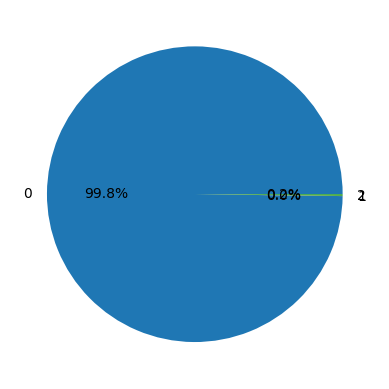

In [50]:
import numpy as np

model = KMeans(n_clusters=3, random_state=random_state)
y_pred_unpreprocessed = model.fit_predict(df)

frequencies = np.unique(y_pred_unpreprocessed, return_counts=True)
plt.pie(frequencies[1], labels=frequencies[0], autopct='%1.1f%%');
plt.show()

# 4) apply a data transformation using the preprocessor below 

In [55]:
from sklearn.preprocessing import PowerTransformer, StandardScaler
from sklearn.pipeline import make_pipeline

preprocessor = make_pipeline(
    StandardScaler(with_std=False),
    PowerTransformer(standardize=True)
)

df_preprocessed = pd.DataFrame(
    preprocessor.fit_transform(df),
    columns=df.columns
)

display(df)
display(df_preprocessed)

,NC_ - 0,NC_ 0- 10,NC_ 10- 15,NC_ 15- 26,NC_ 26- 55,NC_ 55- 75,NC_ 75-120,NC_120-inf,Income_tot
0,0.0,3641.0,1997.0,4567.0,3268.0,413.0,400.0,177.0,347774542.0
1,0.0,50.0,29.0,73.0,41.0,0.0,0.0,0.0,3399810.0
2,0.0,511.0,276.0,792.0,656.0,78.0,48.0,31.0,59153455.0
3,0.0,1303.0,783.0,1820.0,754.0,69.0,33.0,13.0,87615654.0
4,0.0,577.0,194.0,443.0,430.0,26.0,13.0,0.0,30992769.0
...,...,...,...,...,...,...,...,...,...
7886,0.0,126.0,60.0,163.0,87.0,6.0,0.0,4.0,8935126.0
7887,0.0,155.0,104.0,295.0,151.0,16.0,13.0,4.0,15908371.0
7888,0.0,645.0,277.0,374.0,188.0,6.0,5.0,0.0,21065448.0
7889,0.0,350.0,163.0,138.0,62.0,4.0,4.0,0.0,8774861.0


,NC_ - 0,NC_ 0- 10,NC_ 10- 15,NC_ 15- 26,NC_ 26- 55,NC_ 55- 75,NC_ 75-120,NC_120-inf,Income_tot
0,-0.184585,1.422501,1.454164,1.458619,1.526294,1.773109,1.904010,1.953686,1.504214
1,-0.184585,-1.198157,-1.203422,-1.111963,-1.035487,-1.006633,-0.967558,-0.851853,-1.023779
2,-0.184585,-0.304510,-0.166282,0.166057,0.446209,0.979416,0.751146,1.320398,0.295241
3,-0.184585,0.992110,1.183379,1.198832,0.652338,0.795573,0.273971,0.218812,0.919793
4,-0.184585,-0.183012,-0.497791,-0.431993,-0.065329,-0.258736,-0.450439,-0.851853,-0.359388
...,...,...,...,...,...,...,...,...,...
7886,-0.184585,-1.045931,-1.067306,-0.942826,-0.915833,-0.827748,-0.967558,-0.501806,-0.888992
7887,-0.184585,-0.988318,-0.876812,-0.698971,-0.751397,-0.537822,-0.450439,-0.501806,-0.720215
7888,-0.184585,-0.059785,-0.162328,-0.555576,-0.657454,-0.827748,-0.764675,-0.851853,-0.596171
7889,-0.184585,-0.608129,-0.626654,-0.989582,-0.980714,-0.886976,-0.804861,-0.851853,-0.892885


# 5 
find the best clustering scheme for the transformed data, as done instep 

Text(0, 0.5, 'Inertia')

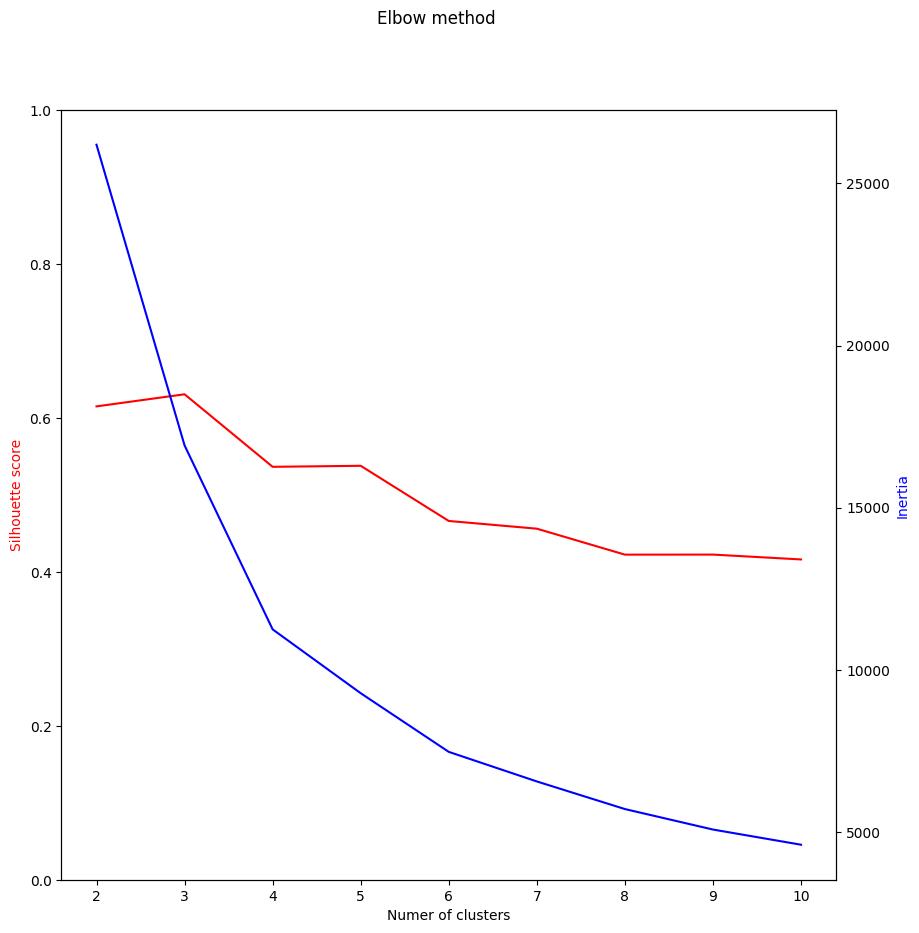

In [52]:
silhouette_list = []
inertia_list = []
ks = [*range(2,11)]
for k in ks:
    model = KMeans(n_clusters=k, random_state=random_state)
    y_pred = model.fit_predict(df_preprocessed)
    silhouette_list.append(silhouette_score(df_preprocessed, y_pred))
    inertia_list.append(model.inertia_)
    
fig, ax1 = plt.subplots(1,1,figsize=[10,10])
fig.suptitle("Elbow method")

color = "r"
ax1.plot(ks, silhouette_list, c=color)
ax1.set_xlabel("Numer of clusters")
ax1.set_ylabel("Silhouette score", c=color)
ax1.set_ylim(0,1)

color = "b"
ax2 = ax1.twinx()
ax2.plot(ks, inertia_list, c=color)
ax2.set_ylabel("Inertia", c=color)

Now we have a elbow in $K=4$ and still a reasonable silhouette score ($\ge 0.5$) so we'll choose 4 as the best clustering schema.

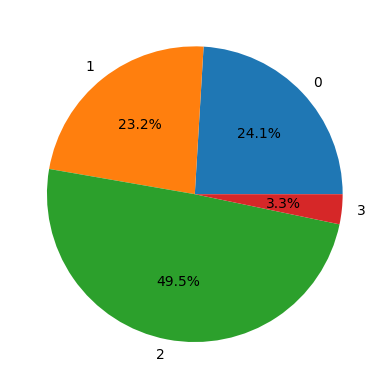

In [53]:
model = KMeans(n_clusters=4, random_state=random_state)
y_pred_preprocessed = model.fit_predict(df_preprocessed)

frequencies = np.unique(y_pred_preprocessed, return_counts=True)
plt.pie(frequencies[1], labels=frequencies[0], autopct='%1.1f%%');
plt.show()

# 6

show together the results of the two clustering schemes obtained andcomment which of the two is better and why . . 

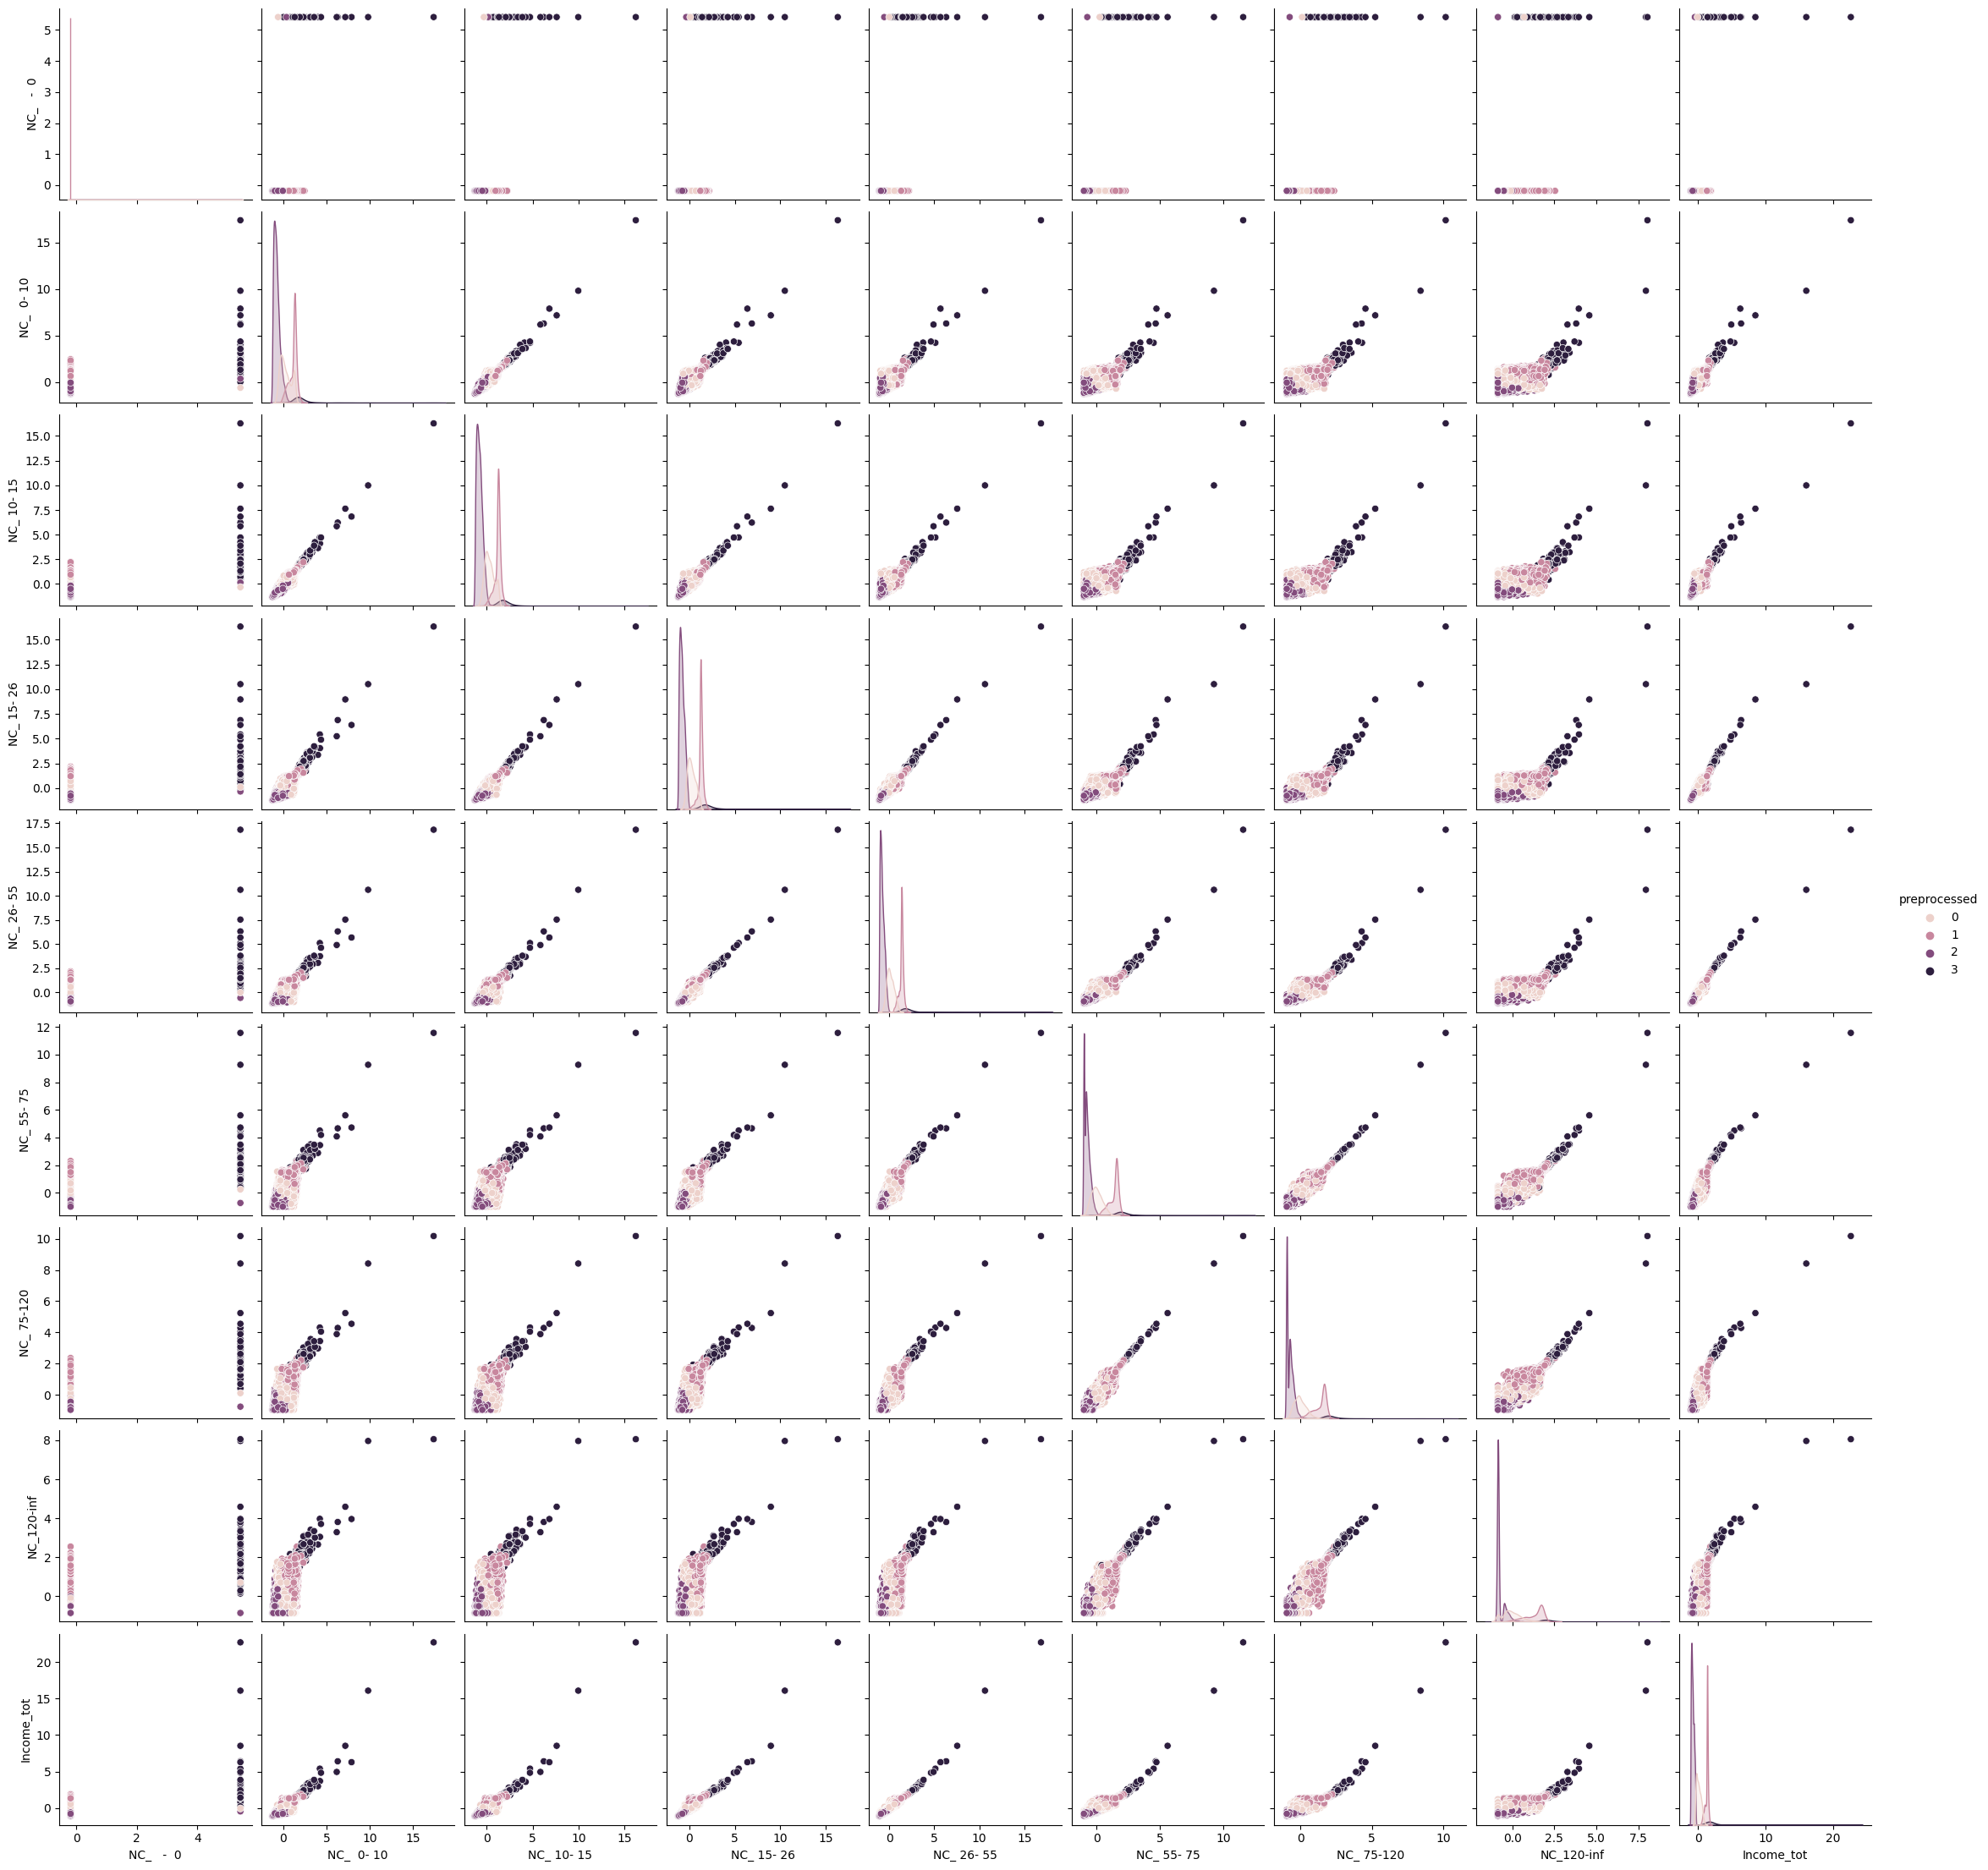

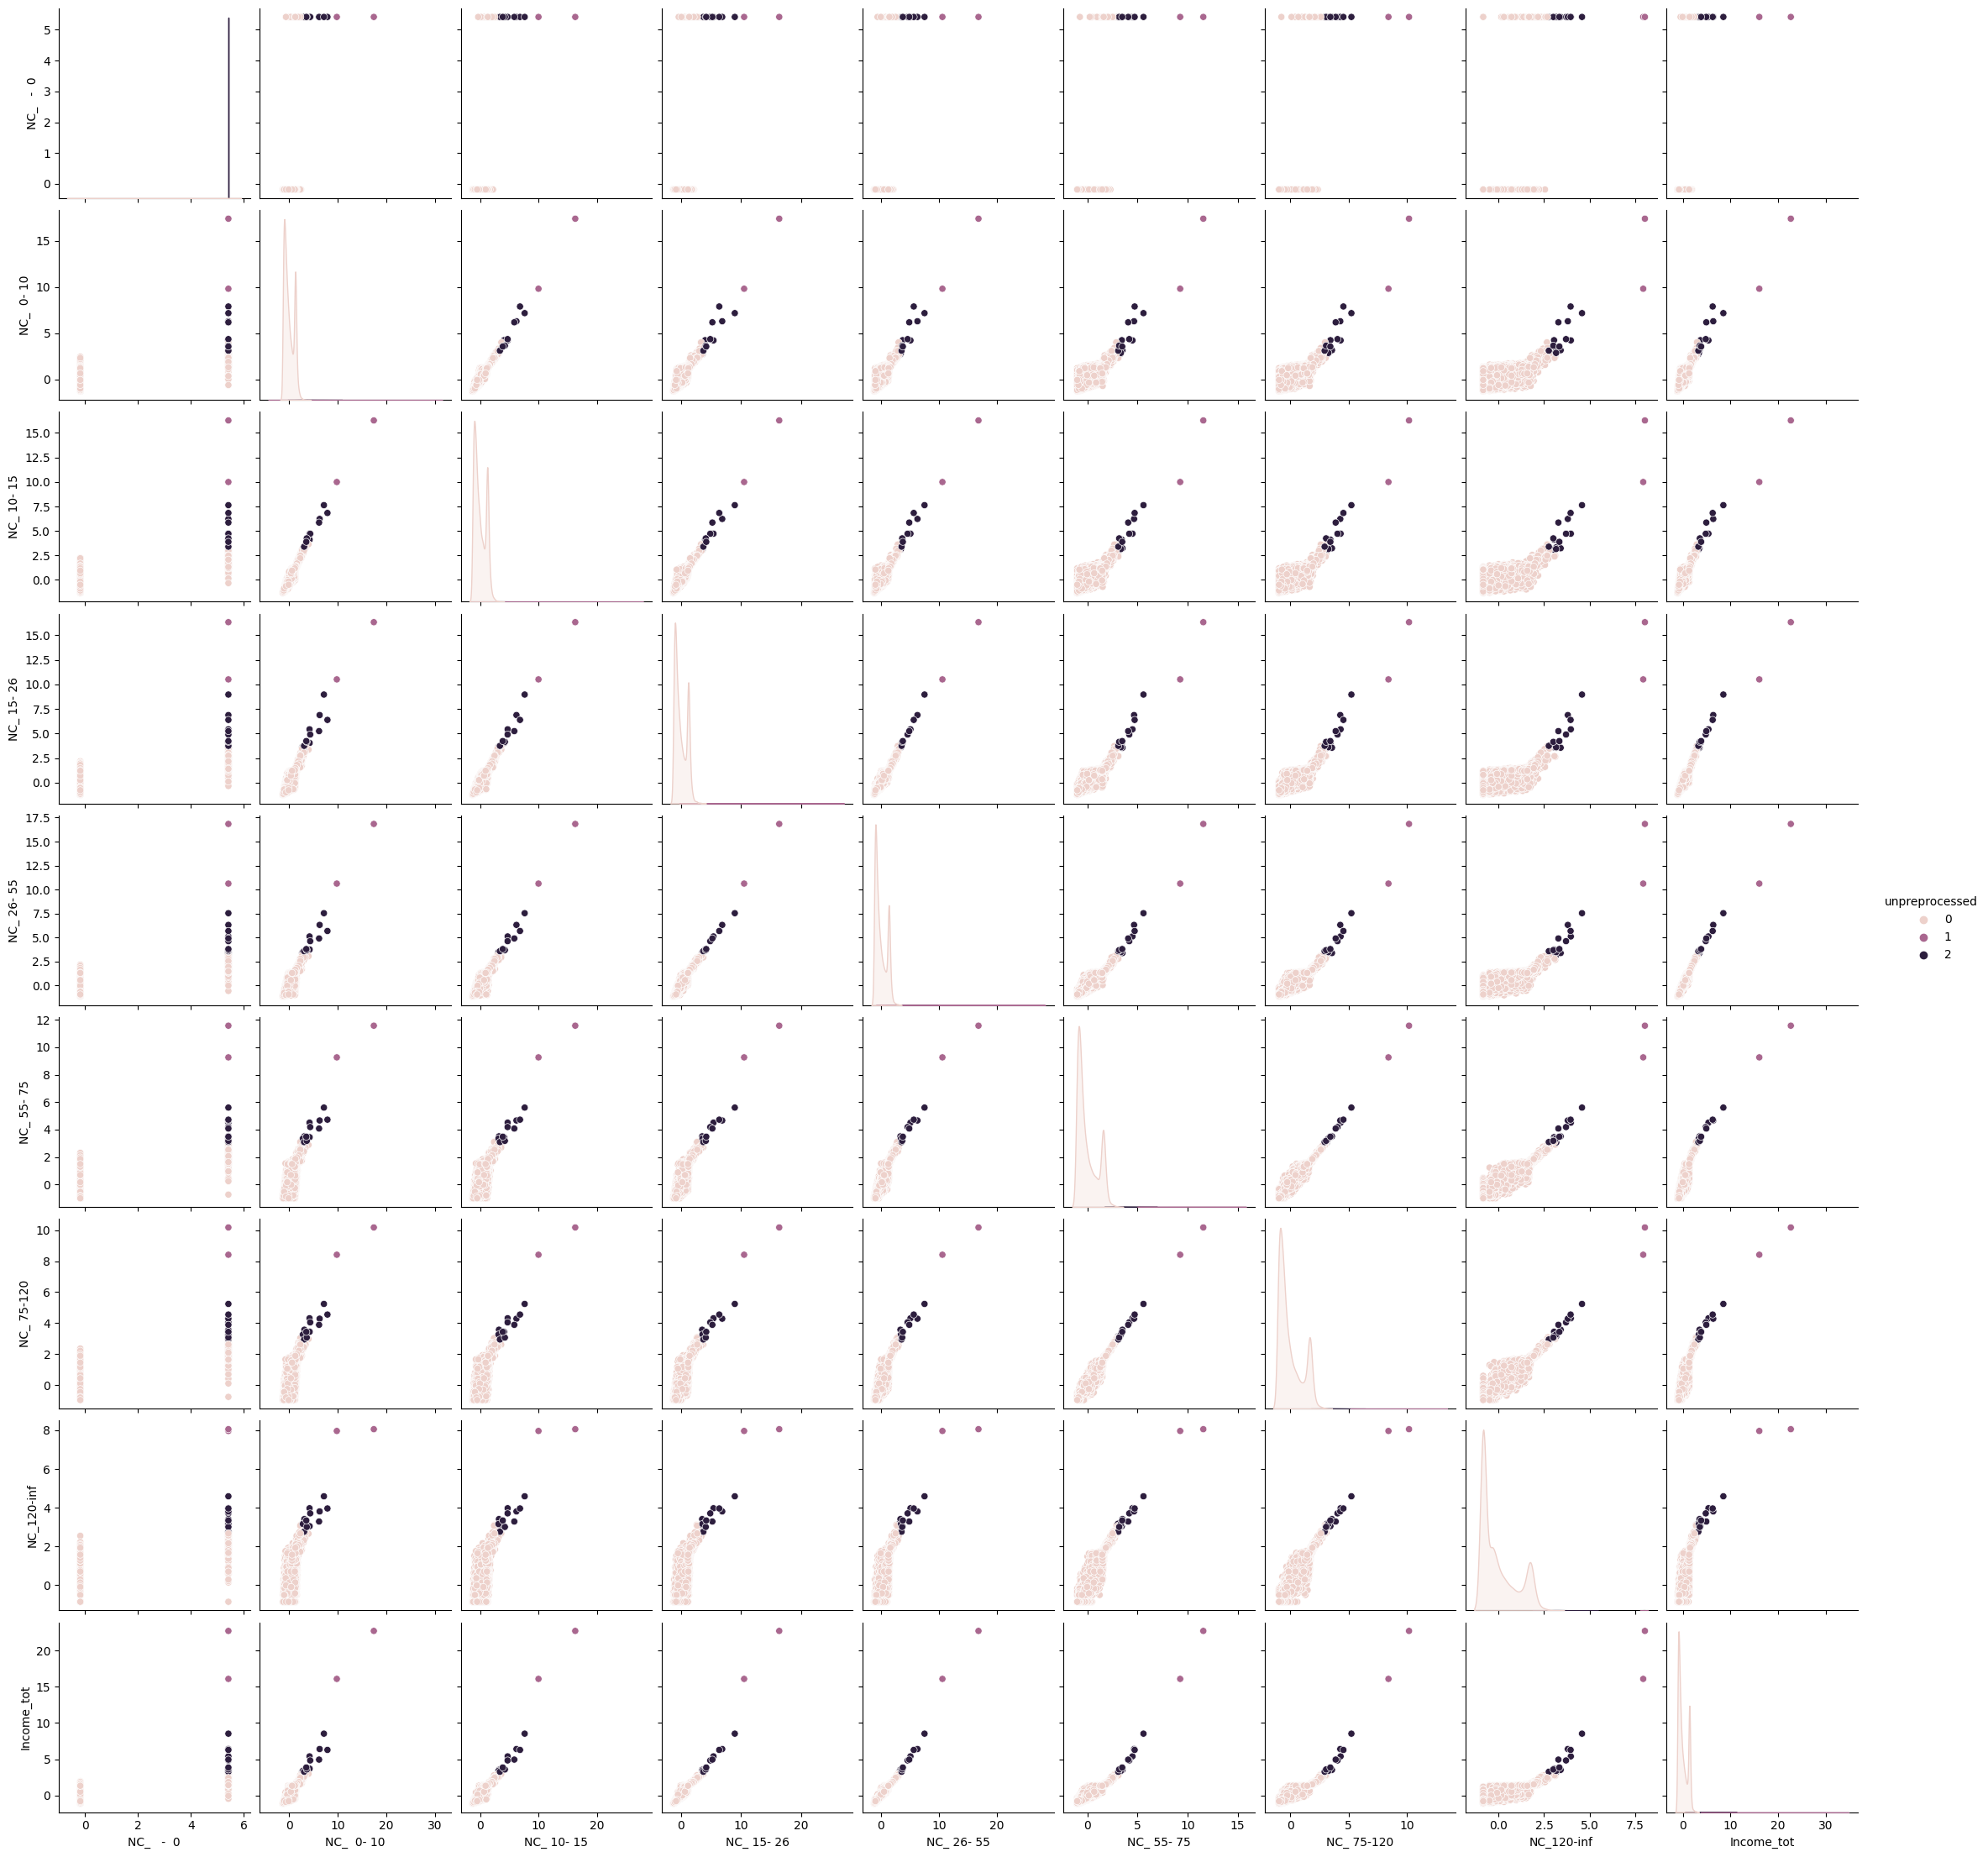

In [ ]:
df_plot = df_preprocessed.copy()
df_plot["unpreprocessed"] = y_pred_unpreprocessed
df_plot["preprocessed"] = y_pred_preprocessed

sns.pairplot(df_plot.drop(columns="preprocessed"), hue="unpreprocessed");
sns.pairplot(df_plot.drop(columns="unpreprocessed"), hue="preprocessed");

As we could have observed by the pieplots (and now is confirmed in the pairplots), the first clustering scheme is too umbalances as 1 class has more of the 99% of the points while in the other one has more balanced clusters and this is due to the range of values of the dataset, with values with too high differences in the orders of magnitude that affects the clustering since K-means in "distance-based".